# EEGNet Classifier for EEG Image Classification

**Task:** Classify which of 20 object categories a subject was viewing from EEG signals (122 channels × 500ms).

**Model:** EEGNet — compact CNN with temporal conv → depthwise spatial conv → separable conv → per-subject heads.

**Reference:** Lawhern et al. (2018) *EEGNet: A Compact Convolutional Network for EEG-based Brain-Computer Interfaces*.

**Expected accuracy:** ~10-16% (chance = 5%). Compared against baseline MLP.

In [31]:
import os, pickle, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla V100-SXM2-32GB


## 1. Data Loading

In [32]:
PROJECT_DIR = '/jet/home/sharmar/eeg-project'
ARTIFACTS    = os.path.join(PROJECT_DIR, 'artifacts')

# Load CSV splits
train_df = pd.read_csv(os.path.join(ARTIFACTS, 'train.csv'))
val_df   = pd.read_csv(os.path.join(ARTIFACTS, 'val.csv'))
test_df  = pd.read_csv(os.path.join(ARTIFACTS, 'test.csv'))

# Load normalization stats, label mappings, bad channels
with open(os.path.join(ARTIFACTS, 'norm_stats.pkl'), 'rb') as f:
    norm_data = pickle.load(f)
with open(os.path.join(ARTIFACTS, 'label_mappings.pkl'), 'rb') as f:
    mappings = pickle.load(f)
with open(os.path.join(ARTIFACTS, 'bad_channels.pkl'), 'rb') as f:
    bad_channels = pickle.load(f)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(f"Categories: {list(mappings['cat_to_idx'].keys())}")
print(f"Subjects: {list(mappings['sub_to_idx'].keys())}")
print(f"Bad channels: {bad_channels}")

Train: 15600, Val: 5200, Test: 5200
Categories: ['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'flower', 'horse', 'motorbike', 'person', 'sheep', 'sofa', 'train', 'tvmonitor']
Subjects: ['sub-02', 'sub-03', 'sub-05', 'sub-09', 'sub-14', 'sub-15', 'sub-17', 'sub-19', 'sub-20', 'sub-23', 'sub-24', 'sub-28', 'sub-29']
Bad channels: {'sub-19': [53, 88], 'sub-29': [82], 'sub-03': []}


## 2. EEGDataset & Collate Function (from data pipeline)

In [33]:
class EEGDataset(Dataset):
    """Loads EEG trials on-the-fly with per-file caching.

    Data on disk: (100, 500, 122) = (trials, timepoints, channels)
    Output:       (122, 500)      = (channels, timepoints)

    Returns:
        eeg_tensor  : (122, 500) float32
        label       : int  (category index)
        subject_id  : int  (subject index)
        metadata    : dict (includes caption for CLIP models)
    """

    def __init__(self, df, normalize='subject_channel', norm_stats=None,
                 clip_threshold=800.0, max_cache=50, bad_channels=None,
                 augment=False):
        self.df = df.reset_index(drop=True)
        self.normalize = normalize
        self.norm_stats = norm_stats
        self.clip_threshold = clip_threshold
        self.max_cache = max_cache
        self.bad_channels = bad_channels or {}
        self.augment = augment
        self._cache = {}
        self._cache_order = []

        self.subjects = sorted(df['subject'].unique())
        self.sub_to_idx = {s: i for i, s in enumerate(self.subjects)}

    def _load_npy(self, path):
        if path not in self._cache:
            if self.max_cache and len(self._cache) >= self.max_cache:
                oldest = self._cache_order.pop(0)
                del self._cache[oldest]
            self._cache[path] = np.load(path)
            self._cache_order.append(path)
        return self._cache[path]

    def _augment(self, eeg):
        """Apply stochastic augmentations to (122, 500) array."""
        # Gaussian noise (σ = 0.1)
        if np.random.rand() < 0.5:
            eeg = eeg + np.random.randn(*eeg.shape).astype(np.float32) * 0.1

        # Temporal shift: ±10 samples (±10ms) — small to preserve ERP timing
        # Zero-pad instead of roll to avoid wrap-around artifacts
        if np.random.rand() < 0.3:
            shift = np.random.randint(-10, 11)
            if shift > 0:
                eeg[:, shift:] = eeg[:, :-shift]
                eeg[:, :shift] = 0.0
            elif shift < 0:
                eeg[:, :shift] = eeg[:, -shift:]
                eeg[:, shift:] = 0.0

        # Channel dropout (zero out ~5% of channels)
        if np.random.rand() < 0.3:
            n_drop = max(1, int(0.05 * eeg.shape[0]))
            drop_idx = np.random.choice(eeg.shape[0], n_drop, replace=False)
            eeg[drop_idx, :] = 0.0

        # Random amplitude scaling (0.9 - 1.1x)
        if np.random.rand() < 0.5:
            scale = np.random.uniform(0.9, 1.1)
            eeg = eeg * scale

        return eeg

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        eeg_all = self._load_npy(row['npy_path'])
        eeg = eeg_all[row['trial_idx']].astype(np.float32)  # (500, 122)

        # Transpose: (500, 122) -> (122, 500) = (channels, timepoints)
        eeg = eeg.T  # (122, 500)

        # Clip extreme amplitudes
        if self.clip_threshold is not None:
            eeg = np.clip(eeg, -self.clip_threshold, self.clip_threshold)

        # Normalize
        if self.normalize == 'subject_channel' and self.norm_stats is not None:
            sub = row['subject']
            mu  = self.norm_stats[sub]['mean'][:, None]   # (122, 1)
            std = self.norm_stats[sub]['std'][:, None]    # (122, 1)
            eeg = (eeg - mu) / std
        elif self.normalize == 'per_trial':
            mu, sigma = eeg.mean(), eeg.std() + 1e-8
            eeg = (eeg - mu) / sigma
        elif self.normalize == 'per_channel':
            mu    = eeg.mean(axis=1, keepdims=True)
            sigma = eeg.std(axis=1, keepdims=True) + 1e-8
            eeg = (eeg - mu) / sigma

        # Zero out bad channels
        sub = row['subject']
        if sub in self.bad_channels and len(self.bad_channels[sub]) > 0:
            eeg[self.bad_channels[sub], :] = 0.0

        # Apply augmentations (after normalization, training only)
        if self.augment:
            eeg = self._augment(eeg)

        eeg_tensor = torch.from_numpy(eeg)  # (122, 500)
        label      = int(row['label'])
        subject_id = self.sub_to_idx[row['subject']]

        metadata = dict(
            subject    = row['subject'],
            session    = row['session'],
            run        = row['run'],
            trial_idx  = row['trial_idx'],
            category   = row['category'],
            image_name = row['image_name'],
            caption    = row.get('caption', ''),
        )
        return eeg_tensor, label, subject_id, metadata


def eeg_collate_fn(batch):
    """Stack tensors, collate metadata into dict-of-lists."""
    eegs, labels, sub_ids, metas = zip(*batch)
    return (
        torch.stack(eegs),                              # (B, 122, 500)
        torch.tensor(labels, dtype=torch.long),         # (B,)
        torch.tensor(sub_ids, dtype=torch.long),        # (B,)
        {k: [m[k] for m in metas] for k in metas[0]},  # dict of lists
    )

In [34]:
# Create datasets and dataloaders
BATCH_SIZE = 64

train_ds = EEGDataset(train_df, normalize='subject_channel',
                      norm_stats=norm_data['per_subject'],
                      clip_threshold=norm_data['clip_threshold'],
                      bad_channels=bad_channels, augment=True)
val_ds   = EEGDataset(val_df, normalize='subject_channel',
                      norm_stats=norm_data['per_subject'],
                      clip_threshold=norm_data['clip_threshold'],
                      bad_channels=bad_channels)
test_ds  = EEGDataset(test_df, normalize='subject_channel',
                      norm_stats=norm_data['per_subject'],
                      clip_threshold=norm_data['clip_threshold'],
                      bad_channels=bad_channels)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=eeg_collate_fn, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=eeg_collate_fn, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=eeg_collate_fn, num_workers=4, pin_memory=True)

# Sanity check
eeg_batch, labels, sub_ids, meta = next(iter(train_loader))
print(f"EEG batch shape: {eeg_batch.shape}")    # (64, 122, 500)
print(f"Labels shape: {labels.shape}")           # (64,)
print(f"Subject IDs shape: {sub_ids.shape}")     # (64,)
print(f"Label range: {labels.min().item()} - {labels.max().item()}")
print(f"Augmentation: ON for train, OFF for val/test")

EEG batch shape: torch.Size([64, 122, 500])
Labels shape: torch.Size([64])
Subject IDs shape: torch.Size([64])
Label range: 0 - 19
Augmentation: ON for train, OFF for val/test


## 3. EEGNet Model

EEGNet processes EEG in three stages:
1. **Block 1** — Temporal conv (learns frequency filters) → depthwise spatial conv (learns electrode weights) → pool
2. **Block 2** — Separable conv (efficient temporal + channel mixing) → pool
3. **Heads** — Shared embedding projection → one classification head per subject


In [35]:
class EEGNet(nn.Module):
    """EEGNet with per-subject classification heads.

    Input:  (B, 122, 500)  — (batch, channels, timepoints)
    Output: logits (B, 20), embedding (B, embed_dim)

    Args:
        n_subjects   : number of subjects (13)
        n_classes    : number of categories (20)
        n_channels   : EEG channels (122)
        n_timepoints : time samples (500)
        F1           : temporal filters in Block 1 (default 8)
        D            : depth multiplier, F2 = F1*D (default 2)
        dropout_rate : dropout probability (default 0.5)
        embed_dim    : shared embedding size before heads (default 64)
    """

    def __init__(self, n_subjects=13, n_classes=20, n_channels=122,
                 n_timepoints=500, F1=8, D=2, dropout_rate=0.5, embed_dim=64):
        super().__init__()
        F2 = F1 * D  # 16

        # Block 1: Temporal conv (frequency filters, kernel = 250ms window)
        self.temporal_conv = nn.Sequential(
            nn.Conv2d(1, F1, kernel_size=(1, 125), padding=(0, 62), bias=False),
            nn.BatchNorm2d(F1),
        )

        # Block 1: Depthwise spatial conv (electrode weights, full spatial extent)
        self.spatial_conv = nn.Sequential(
            nn.Conv2d(F1, F2, kernel_size=(n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),   # 500 -> 125
            nn.Dropout(dropout_rate),
        )

        # Block 2: Separable conv (depthwise + pointwise)
        self.separable_conv = nn.Sequential(
            nn.Conv2d(F2, F2, kernel_size=(1, 16), padding=(0, 8), groups=F2, bias=False),
            nn.Conv2d(F2, F2, kernel_size=(1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),   # 125 -> ~15
            nn.Dropout(dropout_rate),
        )

        # Fix output size regardless of exact arithmetic
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 15))  # (B, F2, 1, 15)

        # Shared embedding (reused for Task 2 CLIP alignment)
        self.embed_proj = nn.Sequential(
            nn.Flatten(),
            nn.Linear(F2 * 15, embed_dim),
            nn.BatchNorm1d(embed_dim),
            nn.ELU(),
            nn.Dropout(dropout_rate * 0.5),
        )

        # Per-subject classification heads (one per subject)
        self.subject_heads = nn.ModuleList([
            nn.Linear(embed_dim, n_classes) for _ in range(n_subjects)
        ])

        self.n_subjects = n_subjects
        self.n_classes  = n_classes
        self.embed_dim  = embed_dim
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.xavier_uniform_(m.weight)
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x, subject_ids):
        """
        Args:
            x           : (B, 122, 500)
            subject_ids : (B,) integer subject indices

        Returns:
            logits    : (B, 20)
            embedding : (B, embed_dim)
        """
        x = x.unsqueeze(1)           # (B, 1, 122, 500)
        x = self.temporal_conv(x)    # (B, F1, 122, 500)
        x = self.spatial_conv(x)     # (B, F2, 1, ~125)
        x = self.separable_conv(x)   # (B, F2, 1, ~15)
        x = self.adaptive_pool(x)    # (B, F2, 1, 15)
        embedding = self.embed_proj(x)  # (B, embed_dim)

        # Selective forward: each sample uses only its subject's head
        logits = torch.zeros(x.size(0), self.n_classes, device=x.device)
        for sub_idx in subject_ids.unique():
            mask = (subject_ids == sub_idx)
            logits[mask] = self.subject_heads[sub_idx](embedding[mask])

        return logits, embedding


model = EEGNet().to(device)
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(model)

Total parameters:     35,996
Trainable parameters: 35,996
EEGNet(
  (temporal_conv): Sequential(
    (0): Conv2d(1, 8, kernel_size=(1, 125), stride=(1, 1), padding=(0, 62), bias=False)
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (spatial_conv): Sequential(
    (0): Conv2d(8, 16, kernel_size=(122, 1), stride=(1, 1), groups=8, bias=False)
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
    (4): Dropout(p=0.5, inplace=False)
  )
  (separable_conv): Sequential(
    (0): Conv2d(16, 16, kernel_size=(1, 16), stride=(1, 1), padding=(0, 8), groups=16, bias=False)
    (1): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ELU(alpha=1.0)
    (4): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
    (5): D

## 4. Training Loop

In [36]:
# Hyperparameters
NUM_EPOCHS   = 50
LR           = 1e-3
WEIGHT_DECAY = 5e-4
PATIENCE     = 10

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-5)

CHECKPOINT_PATH = os.path.join(PROJECT_DIR, 'checkpoints')
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

In [37]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for eeg, labels, sub_ids, meta in loader:
        eeg, labels = eeg.to(device), labels.to(device)
        sub_ids = sub_ids.to(device)
        optimizer.zero_grad()
        logits, _ = model(eeg, sub_ids)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * eeg.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += eeg.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_subs = [], [], []
    for eeg, labels, sub_ids, meta in loader:
        eeg, labels = eeg.to(device), labels.to(device)
        sub_ids = sub_ids.to(device)
        logits, _ = model(eeg, sub_ids)
        loss = criterion(logits, labels)

        total_loss += loss.item() * eeg.size(0)
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total   += eeg.size(0)

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
        all_subs.extend(meta['subject'])

    all_preds  = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    return total_loss / total, correct / total, all_preds, all_labels, all_subs

In [38]:
# Training loop with early stopping
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss    = float('inf')
patience_counter = 0

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _, _ = evaluate(model, val_loader, criterion, device)

    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    elapsed = time.time() - t0
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.2e} | {elapsed:.1f}s")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_acc': val_acc,
        }, os.path.join(CHECKPOINT_PATH, 'eegnet_best.pt'))
        print(f"  -> Saved best model (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)")
            break

print(f"\nBest val loss: {best_val_loss:.4f}")

Epoch 01/50 | Train Loss: 3.2846  Acc: 0.0513 | Val Loss: 3.1248  Acc: 0.0544 | LR: 9.99e-04 | 31.2s
  -> Saved best model (val_loss=3.1248)
Epoch 02/50 | Train Loss: 3.0844  Acc: 0.0531 | Val Loss: 3.0435  Acc: 0.0523 | LR: 9.96e-04 | 31.0s
  -> Saved best model (val_loss=3.0435)
Epoch 03/50 | Train Loss: 3.0421  Acc: 0.0571 | Val Loss: 3.0237  Acc: 0.0537 | LR: 9.91e-04 | 30.7s
  -> Saved best model (val_loss=3.0237)
Epoch 04/50 | Train Loss: 3.0221  Acc: 0.0556 | Val Loss: 3.0173  Acc: 0.0538 | LR: 9.84e-04 | 30.9s
  -> Saved best model (val_loss=3.0173)
Epoch 05/50 | Train Loss: 3.0125  Acc: 0.0621 | Val Loss: 3.0124  Acc: 0.0563 | LR: 9.76e-04 | 31.8s
  -> Saved best model (val_loss=3.0124)
Epoch 06/50 | Train Loss: 2.9997  Acc: 0.0666 | Val Loss: 3.0111  Acc: 0.0594 | LR: 9.65e-04 | 30.8s
  -> Saved best model (val_loss=3.0111)
Epoch 07/50 | Train Loss: 2.9936  Acc: 0.0684 | Val Loss: 3.0056  Acc: 0.0615 | LR: 9.53e-04 | 30.2s
  -> Saved best model (val_loss=3.0056)
Epoch 08/50 |

## 5. Training Curves

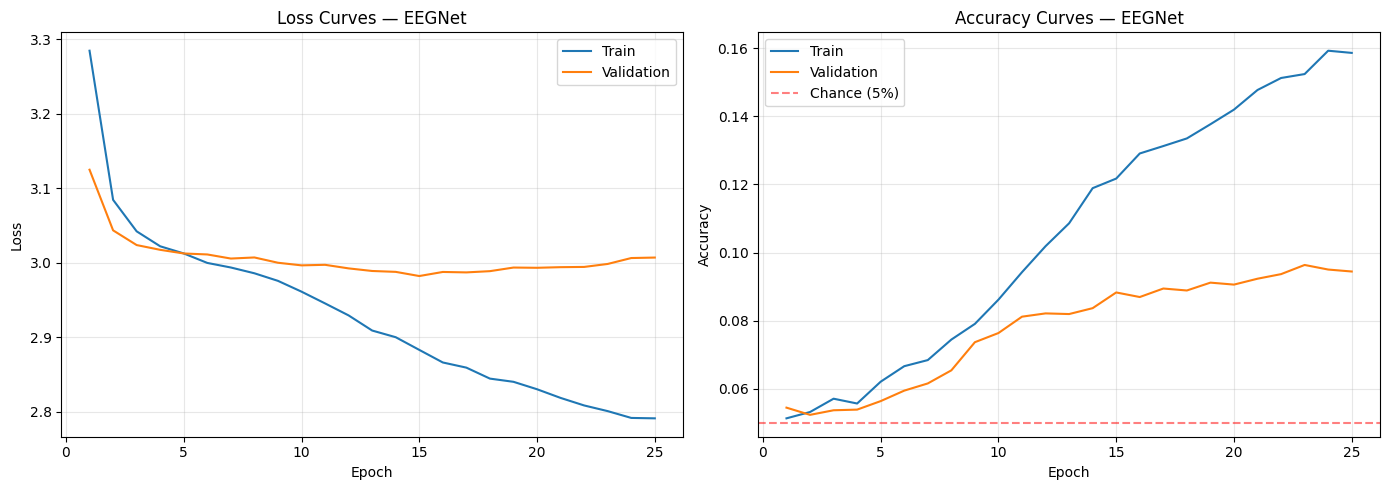

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs_range, history['train_loss'], label='Train')
ax1.plot(epochs_range, history['val_loss'], label='Validation')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curves — EEGNet')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history['train_acc'], label='Train')
ax2.plot(epochs_range, history['val_acc'], label='Validation')
ax2.axhline(y=0.05, color='r', linestyle='--', alpha=0.5, label='Chance (5%)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Curves — EEGNet')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS, 'eegnet_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Test Set Evaluation

In [40]:
# Load best model
ckpt = torch.load(os.path.join(CHECKPOINT_PATH, 'eegnet_best.pt'), map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
print(f"Loaded best model from epoch {ckpt['epoch']} (val_loss={ckpt['val_loss']:.4f}, val_acc={ckpt['val_acc']:.4f})")

# Evaluate on test set
test_loss, test_acc, test_preds, test_labels, test_subs = evaluate(
    model, test_loader, criterion, device
)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Chance level: 5.00%")

Loaded best model from epoch 15 (val_loss=2.9821, val_acc=0.0883)


/var/tmp/ipykernel_68819/2939698020.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(os.path.join(CHECKPOINT_PATH, 'eegnet_best.pt'), map_location=devic


Test Loss: 2.9692
Test Accuracy: 0.0846 (8.46%)
Chance level: 5.00%


### Per-Subject Accuracy

In [41]:
# Per-subject accuracy
subject_correct = {}
subject_total   = {}
for pred, label, sub in zip(test_preds, test_labels, test_subs):
    sub = str(sub)
    if sub not in subject_correct:
        subject_correct[sub] = 0
        subject_total[sub]   = 0
    subject_total[sub]  += 1
    if pred.item() == label.item():
        subject_correct[sub] += 1

print(f"{'Subject':<10} {'Accuracy':>10} {'Correct':>10} {'Total':>8}")
print("-" * 40)
for sub in sorted(subject_correct.keys()):
    acc = subject_correct[sub] / subject_total[sub]
    print(f"{sub:<10} {acc:>10.4f} {subject_correct[sub]:>10} {subject_total[sub]:>8}")

print("\nNote: sub-03, sub-19, sub-20 are known to be noisier.")

Subject      Accuracy    Correct    Total
----------------------------------------
sub-02         0.0675         27      400
sub-03         0.0650         26      400
sub-05         0.0975         39      400
sub-09         0.1125         45      400
sub-14         0.0800         32      400
sub-15         0.0625         25      400
sub-17         0.0950         38      400
sub-19         0.0875         35      400
sub-20         0.0775         31      400
sub-23         0.0700         28      400
sub-24         0.1000         40      400
sub-28         0.1075         43      400
sub-29         0.0775         31      400

Note: sub-03, sub-19, sub-20 are known to be noisier.


### Confusion Matrix

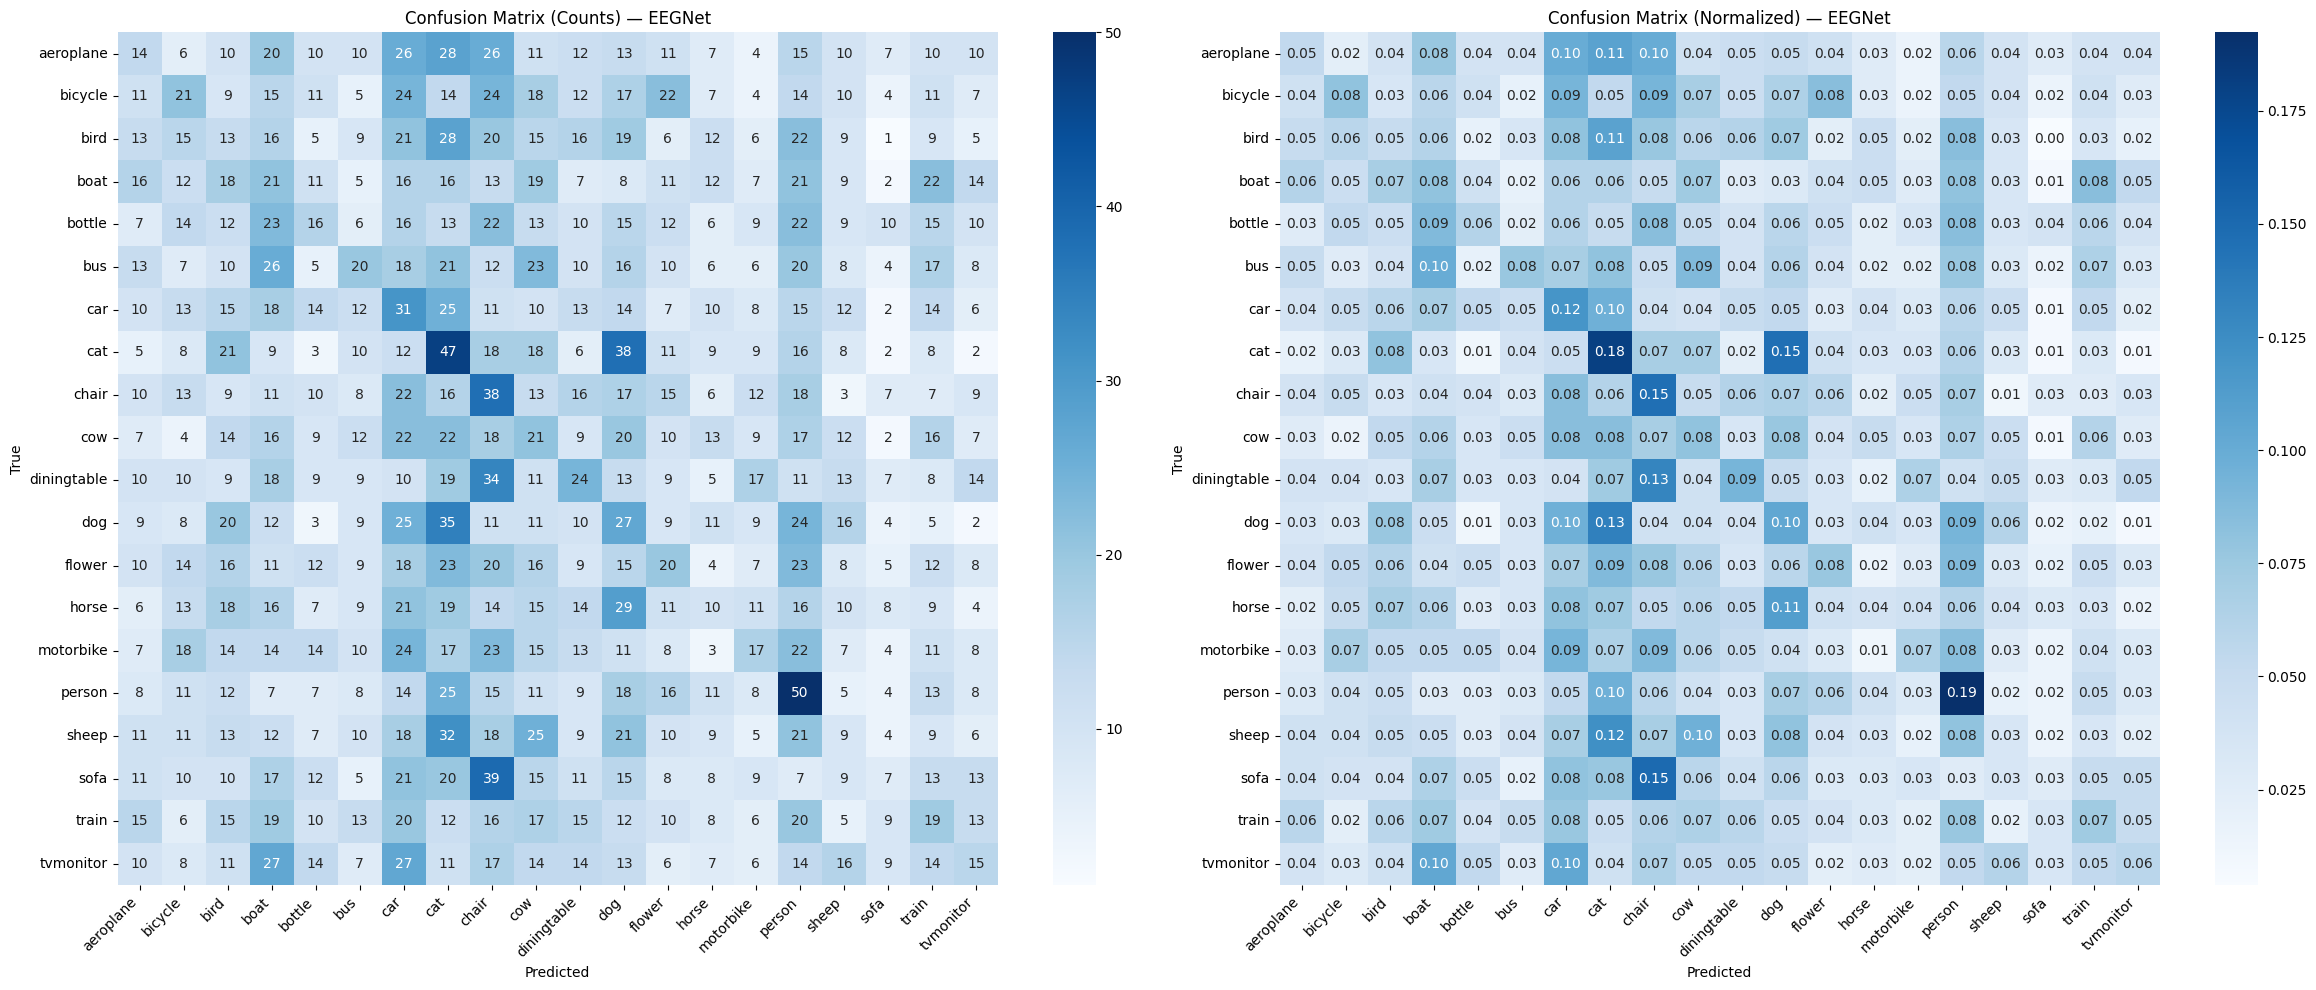

In [42]:
from sklearn.metrics import confusion_matrix

idx_to_cat     = mappings['idx_to_cat']
category_names = [idx_to_cat[i] for i in range(20)]

cm      = confusion_matrix(test_labels.numpy(), test_preds.numpy(), labels=range(20))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=category_names, yticklabels=category_names)
ax1.set_xlabel('Predicted')
ax1.set_ylabel('True')
ax1.set_title('Confusion Matrix (Counts) — EEGNet')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=ax2,
            xticklabels=category_names, yticklabels=category_names)
ax2.set_xlabel('Predicted')
ax2.set_ylabel('True')
ax2.set_title('Confusion Matrix (Normalized) — EEGNet')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS, 'eegnet_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

### Most Confused Category Pairs

In [43]:
# Find most confused pairs (off-diagonal entries)
confused_pairs = []
for i in range(20):
    for j in range(20):
        if i != j:
            confused_pairs.append((category_names[i], category_names[j], cm[i, j]))

confused_pairs.sort(key=lambda x: x[2], reverse=True)

print("Top 15 Most Confused Pairs (True -> Predicted : Count)")
print("-" * 55)
for true_cat, pred_cat, count in confused_pairs[:15]:
    print(f"  {true_cat:<15} -> {pred_cat:<15} : {count}")

Top 15 Most Confused Pairs (True -> Predicted : Count)
-------------------------------------------------------
  sofa            -> chair           : 39
  cat             -> dog             : 38
  dog             -> cat             : 35
  diningtable     -> chair           : 34
  sheep           -> cat             : 32
  horse           -> dog             : 29
  aeroplane       -> cat             : 28
  bird            -> cat             : 28
  tvmonitor       -> boat            : 27
  tvmonitor       -> car             : 27
  aeroplane       -> car             : 26
  aeroplane       -> chair           : 26
  bus             -> boat            : 26
  car             -> cat             : 25
  dog             -> car             : 25


## 7. Kaggle Submission CSV

In [44]:
# Generate Kaggle submission CSV
submission = pd.DataFrame({
    'Id':       range(len(test_preds)),
    'Category': test_preds.numpy(),
})
submission_path = os.path.join(PROJECT_DIR, 'submission_eegnet.csv')
submission.to_csv(submission_path, index=False)
print(f"Submission saved to {submission_path}")
print(f"Shape: {submission.shape}")
print(submission.head(10))

Submission saved to /jet/home/sharmar/eeg-project/submission_eegnet.csv
Shape: (5200, 2)
   Id  Category
0   0        15
1   1        16
2   2        13
3   3        16
4   4        12
5   5        16
6   6        12
7   7        16
8   8         2
9   9        15


### 8. Summary

In [45]:
print("=" * 60)
print("EEGNET SUMMARY")
print("=" * 60)
print(f"Architecture: Temporal conv -> Depthwise spatial -> Separable -> Per-subject heads")
print(f"Parameters: {total_params:,}")
print(f"Best epoch: {ckpt['epoch']}")
print(f"Best val loss: {ckpt['val_loss']:.4f}")
print(f"Best val acc: {ckpt['val_acc']:.4f} ({ckpt['val_acc']*100:.2f}%)")
print(f"Test acc: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Chance level: 5.00%")
print(f"Checkpoint: {os.path.join(CHECKPOINT_PATH, 'eegnet_best.pt')}")
print(f"Submission: {submission_path}")
print("=" * 60)

EEGNET SUMMARY
Architecture: Temporal conv -> Depthwise spatial -> Separable -> Per-subject heads
Parameters: 35,996
Best epoch: 15
Best val loss: 2.9821
Best val acc: 0.0883 (8.83%)
Test acc: 0.0846 (8.46%)
Chance level: 5.00%
Checkpoint: /jet/home/sharmar/eeg-project/checkpoints/eegnet_best.pt
Submission: /jet/home/sharmar/eeg-project/submission_eegnet.csv
